# Semantic Ranking

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Retrieval function
from src.retrieval import retrieve_top_k, compute_scores

In [3]:
# Load data
data_path_processed = PROJECT_ROOT / "data/processed/arxiv_papers.csv"

data = pd.read_csv(data_path_processed)
print(f"Shape of data: {data.shape}")
data.head()

Shape of data: (1000, 6)


,id,title,summary,category,published,combined
0,2012.11510v1,Design Rule Checking with a CNN Based Feature ...,Design rule checking (DRC) is getting increasi...,cs.LG,2020,design rule checking with a cnn based feature ...
1,2012.11638v1,Unsupervised in-distribution anomaly detection...,Anomaly detection is a key application of mach...,cs.LG|hep-ex|physics.data-an,2020,unsupervised in-distribution anomaly detection...
2,2012.11325v1,Detecting Botnet Attacks in IoT Environments: ...,The increased reliance on the Internet and the...,cs.CR|cs.LG|cs.NI,2020,detecting botnet attacks in iot environments: ...
3,2012.11327v1,Collaborative residual learners for automatic ...,Clinical coding is an administrative process t...,cs.IR|cs.LG,2020,collaborative residual learners for automatic ...
4,2012.11333v1,Ensemble model for pre-discharge icd10 coding ...,The translation of medical diagnosis to clinic...,cs.IR|cs.LG,2020,ensemble model for pre-discharge icd10 coding ...


## TF-IDF Baseline

In [4]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = vectorizer.fit_transform(data['combined']) # Creates vocabulary and transforms it into a sparse matrix

In [5]:
# Example query vectorization
query = "self-supervised learning for image representation"
query_vector = vectorizer.transform([query])

In [6]:
# Compute cosine similarity between query and documents
tfidf_scores = cosine_similarity(query_vector, tfidf_matrix)[0]
data['tfidf_score'] = tfidf_scores

In [7]:
# show title and score of top 5 results
data_sorted = data.sort_values(by='tfidf_score', ascending=False)

with pd.option_context('display.max_colwidth', None):
    display(data_sorted[['title', 'tfidf_score']].head(5))

,title,tfidf_score
966,CompRess: Self-Supervised Learning by Compressing Representations,0.505440
384,Look Listen and Attend: Co-Attention Network for Self-Supervised Audio-Visual Representation Learning,0.248077
510,Uncovering the structure of clinical EEG signals with self-supervised learning,0.229153
814,SLM: Learning a Discourse Language Representation with Sentence Unshuffling,0.207946
93,Self-supervised Body Image Acquisition Using a Deep Neural Network for Sensorimotor Prediction,0.204004


## SBERT Embedding Similarity

In [ ]:
# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

In [9]:
# Encode entire data
embeddings = model.encode(data['combined'].tolist(), batch_size = 32, show_progress_bar=True)

# normalize embeddings
embeddings = normalize(embeddings)
embeddings.shape

Batches: 100%|██████████| 32/32 [00:36<00:00,  1.15s/it]


(1000, 384)

In [10]:
# Save embeddings for reuseability
path_embeddings = PROJECT_ROOT / "data/processed/arxiv_embeddings.npy"
np.save(path_embeddings, embeddings)

In [11]:
# Load embeddings
embeddings = np.load(path_embeddings)
embeddings.shape

(1000, 384)

In [12]:
def plot_score_distributions(query, preferred_category, df, embeddings, model, tfidf_scores):

    final_scores = compute_scores(query, preferred_category, df, embeddings, model)['final_score']

    plt.figure(figsize=(6,4))
    plt.hist(tfidf_scores, bins=40, alpha=0.6, label="TF-IDF")
    plt.hist(final_scores, bins=40, alpha=0.6, label="Final score")

    plt.xlabel("Similarity Score")
    plt.ylabel("Number of Papers")
    plt.title("Similarity Score Distribution")
    plt.legend()

    plt.show()

In [13]:
def display_top_k(query, preferred_category, df, embeddings, model, k=5):

    results = retrieve_top_k(query, preferred_category, df, embeddings, model, k)

    for _,row in results.iterrows():
        print(f"\nTitle: {row['title']}")
        print(f"Score: {row['final_score']:.3f}")
        print(f"Category: {row['category']}")
        print(f"Abstract Preview: {row['summary'][:200]}...")
        print("-"*80)

## Example query results

In [14]:
example1 = display_top_k("self-supervised learning for image representation", "cs.CV", data, embeddings, model)


Title: A Framework For Contrastive Self-Supervised Learning And Designing A New Approach
Score: 0.569
Category: cs.CV|cs.LG
Abstract Preview: Contrastive self-supervised learning (CSL) is an approach to learn useful representations by solving a pretext task that selects and compares anchor negative and positive (APN) features from an unlabe...
--------------------------------------------------------------------------------

Title: CompRess: Self-Supervised Learning by Compressing Representations
Score: 0.558
Category: cs.CV|cs.LG
Abstract Preview: Self-supervised learning aims to learn good representations with unlabeled data. Recent works have shown that larger models benefit more from self-supervised learning than smaller models. As a result ...
--------------------------------------------------------------------------------

Title: Learning Representations by Maximizing Mutual Information Across Views
Score: 0.495
Category: cs.LG|stat.ML
Abstract Preview: We propose an approach to 

In [15]:
example2 =display_top_k("transformer models for language understanding", "cs.LG", data, embeddings, model)


Title: Accelerating Training of Transformer-Based Language Models with Progressive Layer Dropping
Score: 0.611
Category: cs.LG
Abstract Preview: Recently Transformer-based language models have demonstrated remarkable performance across many NLP domains. However the unsupervised pre-training step of these models suffers from unbearable overall ...
--------------------------------------------------------------------------------

Title: SLM: Learning a Discourse Language Representation with Sentence Unshuffling
Score: 0.552
Category: cs.CL|cs.LG
Abstract Preview: We introduce Sentence-level Language Modeling a new pre-training objective for learning a discourse language representation in a fully self-supervised manner. Recent pre-training methods in NLP focus ...
--------------------------------------------------------------------------------

Title: Multitask Learning and Joint Optimization for Transformer-RNN-Transducer Speech Recognition
Score: 0.535
Category: cs.LG|cs.SD|eess.AS
Abst

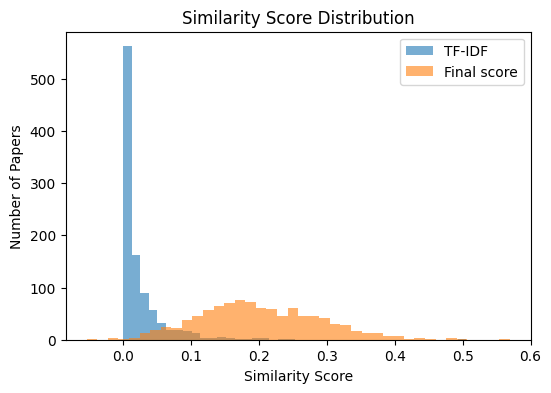

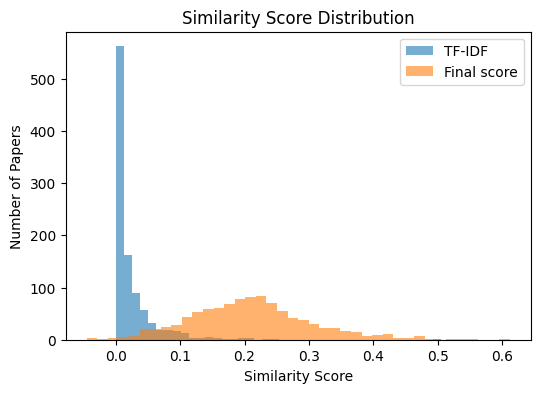

In [16]:
plot_score_distributions("self-supervised learning for image representation", "cs.CV", data, embeddings, model, tfidf_scores)
plot_score_distributions("transformer models for language understanding", "cs.LG", data, embeddings, model, tfidf_scores)